<a href="https://colab.research.google.com/github/Pedro4Albuquerque/09-DIS-Disney-Dire-o-de-Volume/blob/main/neuroalgoritmos_pedro_souza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09: DIS (Disney) | Direção de Volume:
**Alvo (Y):** 1 (Crescente) ou 0 (Decrescente) em relação ao dia anterior.

**Desafio:** Prever se o fechamento atual é influenciado pelo volume da véspera.
## Aluno : Pedro Henrique Albuquerque Souza

# Pipeline 1 | Carregamento e Digestão dos Dados via API [DIS - Disney]

In [1]:

from typing import List
import requests
import pandas as pd

API_KEY = "YF91FPXACQJ396DA"
SYMBOL = "DIS"

url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={SYMBOL}&outputsize=compact&apikey={API_KEY}'
r = requests.get(url)
data = r.json()

dados = data["Time Series (Daily)"]

base_dis = pd.DataFrame.from_dict(
    dados,
    orient="index"
)

base_dis

,1. open,2. high,3. low,4. close,5. volume
2026-06-18,101.8000,104.2200,100.8000,103.8900,22943613
2026-06-17,100.6700,102.3600,100.4400,100.8600,11168735
2026-06-16,101.4300,101.9300,100.0500,101.2800,10694557
2026-06-15,100.8800,102.4000,100.5900,101.6900,10265095
2026-06-12,101.0600,101.7685,99.5350,100.0400,8257240
...,...,...,...,...,...
2026-02-02,104.0100,108.6100,103.7500,104.4500,37778503
2026-01-30,111.3600,112.9450,110.9900,112.8000,17895224
2026-01-29,109.6300,111.6700,108.7600,111.5800,11078959
2026-01-28,110.2800,111.4299,109.0000,109.5600,9016629


## Blibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Organização e Limpeza

In [4]:
base_dis.index = pd.to_datetime(base_dis.index)

base_dis = base_dis.rename(columns={
    "1. open": "Open",
    "2. high": "High",
    "3. low": "Low",
    "4. close": "Close",
    "5. volume": "Volume"
})

base_dis = base_dis.astype(float)

base_dis = base_dis.sort_index()

base_dis

,Open,High,Low,Close,Volume
2026-01-27,111.50,111.8000,110.030,110.61,8888859.0
2026-01-28,110.28,111.4299,109.000,109.56,9016629.0
2026-01-29,109.63,111.6700,108.760,111.58,11078959.0
2026-01-30,111.36,112.9450,110.990,112.80,17895224.0
2026-02-02,104.01,108.6100,103.750,104.45,37778503.0
...,...,...,...,...,...
2026-06-12,101.06,101.7685,99.535,100.04,8257240.0
2026-06-15,100.88,102.4000,100.590,101.69,10265095.0
2026-06-16,101.43,101.9300,100.050,101.28,10694557.0
2026-06-17,100.67,102.3600,100.440,100.86,11168735.0


## Análise Exploratória

 Mostra informações gerais da tabela.

In [5]:
base_dis.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2026-01-27 to 2026-06-18
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    100 non-null    float64
 1   High    100 non-null    float64
 2   Low     100 non-null    float64
 3   Close   100 non-null    float64
 4   Volume  100 non-null    float64
dtypes: float64(5)
memory usage: 4.7 KB


 Gera estatísticas automáticas das colunas numéricas.

In [6]:
base_dis.describe()

,Open,High,Low,Close,Volume
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,102.680700,103.811126,101.535598,102.625800,1.055151e+07
std,3.829874,3.950703,3.688168,3.889167,5.034885e+06
min,92.890000,94.190000,92.185000,92.420000,5.533717e+06
25%,100.035000,100.983750,99.017500,99.770000,7.820982e+06
50%,102.790000,103.882500,101.695000,102.785000,9.231053e+06
75%,105.030000,106.332500,103.968750,104.990000,1.142439e+07
max,111.500000,112.945000,110.990000,112.800000,3.777850e+07


### Verifica valores vazios (NaN) na tabela.

In [7]:
base_dis.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


### Visualização de Dados

Nesta etapa serão apresentados gráficos relacionados ao fechamento e volume da ação, permitindo observar padrões e oscilações do mercado.

Fechamento das ações

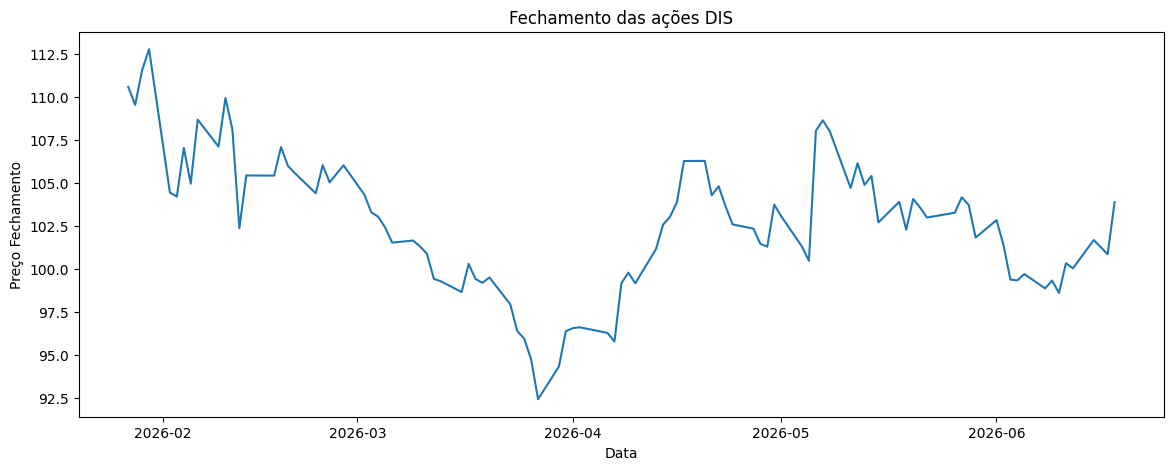

In [8]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Close"])

plt.title("Fechamento das ações DIS")
plt.xlabel("Data")
plt.ylabel("Preço Fechamento")

plt.show()

 Volume negociado

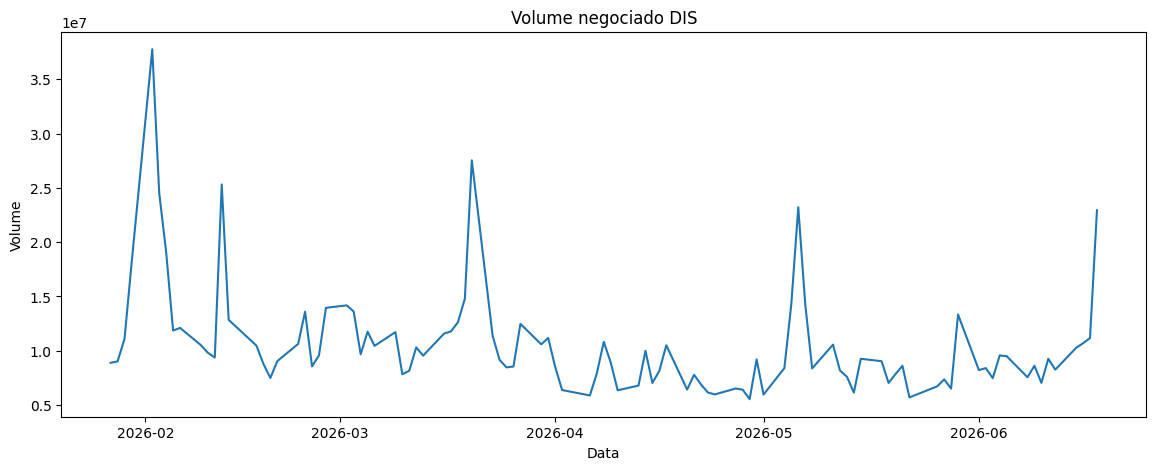

In [9]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Volume"])

plt.title("Volume negociado DIS")
plt.xlabel("Data")
plt.ylabel("Volume")

plt.show()

Correlação

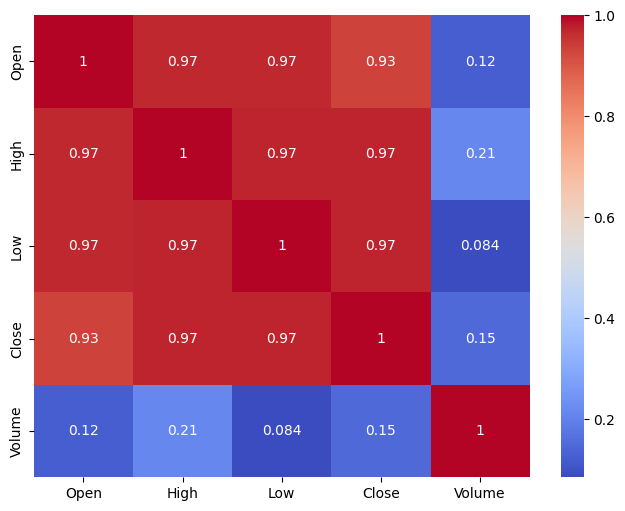

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    base_dis.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

##Engenharia de Features

 Criação do alvo Y

In [11]:
base_dis["fechamento_anterior"] = base_dis["Close"].shift(1)

base_dis["direcao"] = np.where(
    base_dis["Close"] > base_dis["fechamento_anterior"],
    1,
    0
)

Volume da véspera

In [12]:
base_dis["volume_anterior"] = base_dis["Volume"].shift(1)

Removendo valores nulos

In [13]:
base_dis.dropna(inplace=True)

### Separação X e Y

In [14]:
X_dis = base_dis[
    [
      "volume_anterior"
    ]
].values

Y_dis = base_dis["direcao"].values

## Normalização

In [15]:
from sklearn.model_selection import train_test_split
X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(
    X_dis,
    Y_dis,
    test_size=0.20,
    random_state=0,
    shuffle=False
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_treinamento = scaler.fit_transform(X_treinamento)
X_teste = scaler.transform(X_teste)

In [17]:
base_dis.to_csv("dados_disney_limpos.csv")

# Pipeline Tree Map | Arvore de Decisão

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
arvore_dis_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_dis_data.fit(X_treinamento, Y_treinamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [20]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion="entropy",
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='best')

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [21]:
previsoes_arvore = arvore_dis_data.predict(X_teste)
previsoes_arvore

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1])

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
accuracy_score(Y_teste, previsoes_arvore)

0.7

In [24]:
from yellowbrick.classifier import ConfusionMatrix

0.7

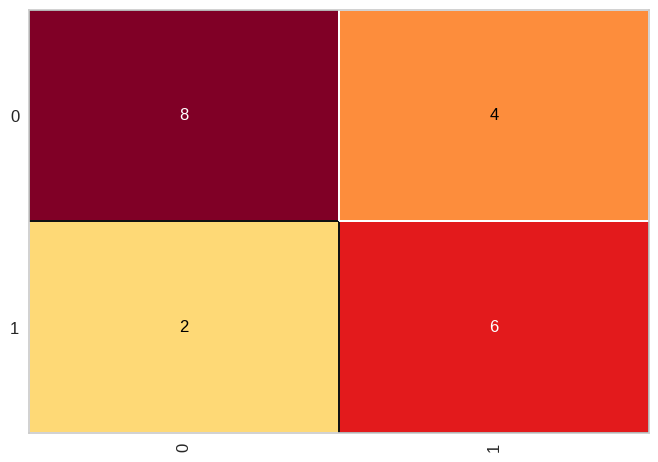

In [25]:
cm_tree = ConfusionMatrix(arvore_dis_data)
cm_tree.fit(X_treinamento, Y_treinamento)
cm_tree.score(X_teste, Y_teste)

In [26]:
print(classification_report(Y_teste, previsoes_arvore))

              precision    recall  f1-score   support

           0       0.80      0.67      0.73        12
           1       0.60      0.75      0.67         8

    accuracy                           0.70        20
   macro avg       0.70      0.71      0.70        20
weighted avg       0.72      0.70      0.70        20



# Pipeline Random Florest

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix

In [28]:
random_dis = RandomForestClassifier(n_estimators=10, criterion='entropy', max_features='sqrt', random_state=0)

In [29]:
random_dis.fit(X_treinamento, Y_treinamento)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [30]:
previsores_random = random_dis.predict(X_teste)
previsores_random

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1])

In [31]:
print("Acurácia do Random Forest:", accuracy_score(Y_teste, previsores_random))

Acurácia do Random Forest: 0.6


In [32]:
print("\nRelatório de Classificação:")
print(classification_report(Y_teste, previsores_random))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.70      0.58      0.64        12
           1       0.50      0.62      0.56         8

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.62      0.60      0.60        20



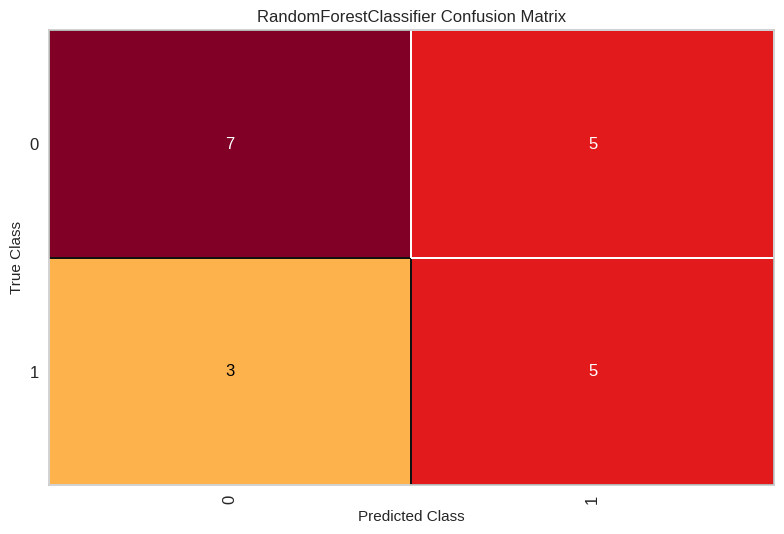

<Axes: title={'center': 'RandomForestClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [33]:
cm_dis_rf = ConfusionMatrix(random_dis)
cm_dis_rf.fit(X_treinamento, Y_treinamento)
cm_dis_rf.score(X_teste, Y_teste)
cm_dis_rf.show()

# Pipeline SVM

In [34]:
from sklearn.svm import SVC

In [35]:
svm_dis = SVC(kernel='rbf', random_state=1, C=2.0)
svm_dis.fit(X_treinamento, Y_treinamento)

SVC(C=2.0, random_state=1)

In [36]:
SVC(C=2.0,break_ties=False,cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=0, shrinking=True, tol=0.001,
    verbose = False)

SVC(C=2.0, random_state=0)

In [37]:
svm_previsoes = svm_dis.predict(X_teste)
svm_previsoes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [38]:
accuracy_score(Y_teste, svm_previsoes)

0.6

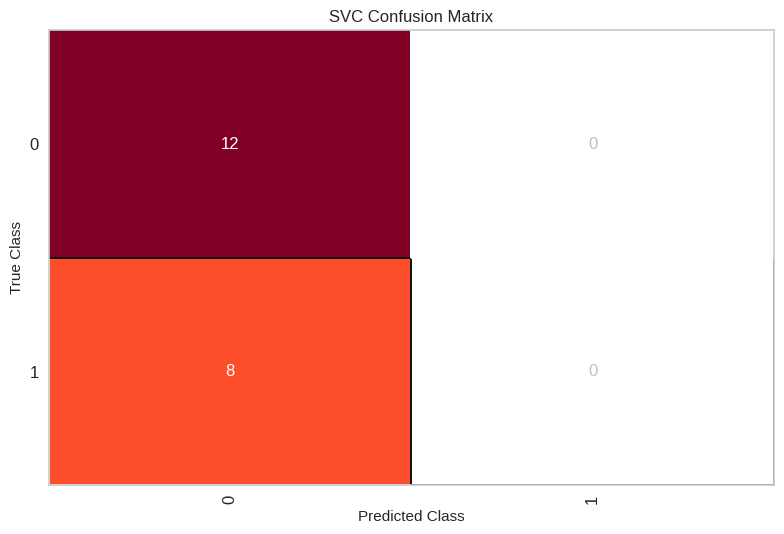

<Axes: title={'center': 'SVC Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [39]:
svm_dis_cm = ConfusionMatrix(svm_dis)
svm_dis_cm.fit(X_treinamento, Y_treinamento)
svm_dis_cm.score(X_teste, Y_teste)
svm_dis_cm.show()

In [40]:
print(classification_report(Y_teste, svm_previsoes))

              precision    recall  f1-score   support

           0       0.60      1.00      0.75        12
           1       0.00      0.00      0.00         8

    accuracy                           0.60        20
   macro avg       0.30      0.50      0.38        20
weighted avg       0.36      0.60      0.45        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Redes Neurais Artificiais

In [41]:
from sklearn.neural_network import MLPClassifier

In [42]:
redeneural_dis = MLPClassifier(verbose=True, max_iter=1000, tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_dis.fit(X_treinamento, Y_treinamento)

Iteration 1, loss = 0.69271367
Iteration 2, loss = 0.69136575
Iteration 3, loss = 0.69008518
Iteration 4, loss = 0.68888429
Iteration 5, loss = 0.68775851
Iteration 6, loss = 0.68669644
Iteration 7, loss = 0.68570394
Iteration 8, loss = 0.68478964
Iteration 9, loss = 0.68394619
Iteration 10, loss = 0.68316973
Iteration 11, loss = 0.68245757
Iteration 12, loss = 0.68180614
Iteration 13, loss = 0.68121199
Iteration 14, loss = 0.68067347
Iteration 15, loss = 0.68019214
Iteration 16, loss = 0.67976590
Iteration 17, loss = 0.67939060
Iteration 18, loss = 0.67905541
Iteration 19, loss = 0.67875983
Iteration 20, loss = 0.67849945
Iteration 21, loss = 0.67827165
Iteration 22, loss = 0.67807006
Iteration 23, loss = 0.67789043
Iteration 24, loss = 0.67772837
Iteration 25, loss = 0.67757901
Iteration 26, loss = 0.67744365
Iteration 27, loss = 0.67731931
Iteration 28, loss = 0.67719875
Iteration 29, loss = 0.67708327
Iteration 30, loss = 0.67696652
Iteration 31, loss = 0.67684977
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [43]:
redeneural_dis.out_activation_

'logistic'

In [44]:
previsores_randeural = redeneural_dis.predict(X_teste)
previsores_randeural

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1])

In [45]:
accuracy_score(Y_teste, redeneural_dis.predict(X_teste))

0.55

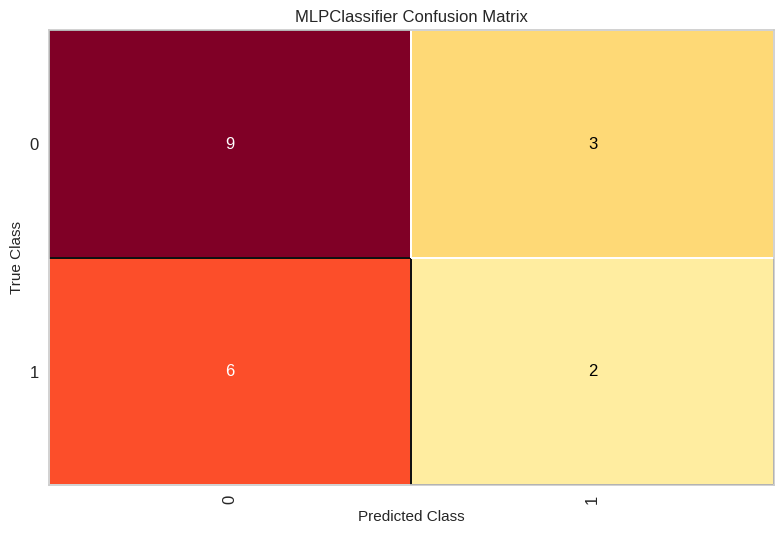

In [46]:
rn_cm= ConfusionMatrix(redeneural_dis)
rn_cm.fit(X_treinamento, Y_treinamento)
rn_cm.score(X_teste, Y_teste)
rn_cm.show();

In [47]:
print(classification_report(Y_teste, previsores_randeural))

              precision    recall  f1-score   support

           0       0.60      0.75      0.67        12
           1       0.40      0.25      0.31         8

    accuracy                           0.55        20
   macro avg       0.50      0.50      0.49        20
weighted avg       0.52      0.55      0.52        20



# Pipeline K-Nearest Neighbors (KNN)

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [49]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=2)

In [50]:
parametros = {'n_neighbors': [3, 5, 10],
              'p': [1, 2]}

In [51]:
grid_dis = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=parametros,
    cv=tscv
)

In [52]:
grid_dis.fit(X_treinamento, Y_treinamento)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=2, test_size=None),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 10], 'p': [1, 2]})

In [53]:
melhor_paremetro_dis = grid_dis.best_params_
melhor_resultado_dis = grid_dis.best_score_

print("Melhor parâmetro:", melhor_paremetro_dis)
print("Melhor resultado:", melhor_resultado_dis)

Melhor parâmetro: {'n_neighbors': 5, 'p': 1}
Melhor resultado: 0.6346153846153846


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn_dis = grid_dis.best_estimator_

previsores_knn = knn_dis.predict(X_teste)

In [58]:
acuracia_knn = accuracy_score(Y_teste, previsores_knn)
precisao_knn = precision_score(Y_teste, previsores_knn, average="weighted", zero_division=0)
recall_knn = recall_score(Y_teste, previsores_knn, average="weighted", zero_division=0)
f1_knn = f1_score(Y_teste, previsores_knn, average="weighted", zero_division=0)


In [59]:
print("Acurácia do KNN:", acuracia_knn)
print("Precisão Weighted do KNN:", precisao_knn)
print("Recall Weighted do KNN:", recall_knn)
print("F1-Score Weighted do KNN:", f1_knn)

print("\nRelatório de Classificação - KNN:")
print(classification_report(Y_teste, previsores_knn, zero_division=0))

Acurácia do KNN: 0.5
Precisão Weighted do KNN: 0.5
Recall Weighted do KNN: 0.5
F1-Score Weighted do KNN: 0.5

Relatório de Classificação - KNN:
              precision    recall  f1-score   support

           0       0.58      0.58      0.58        12
           1       0.38      0.38      0.38         8

    accuracy                           0.50        20
   macro avg       0.48      0.48      0.48        20
weighted avg       0.50      0.50      0.50        20



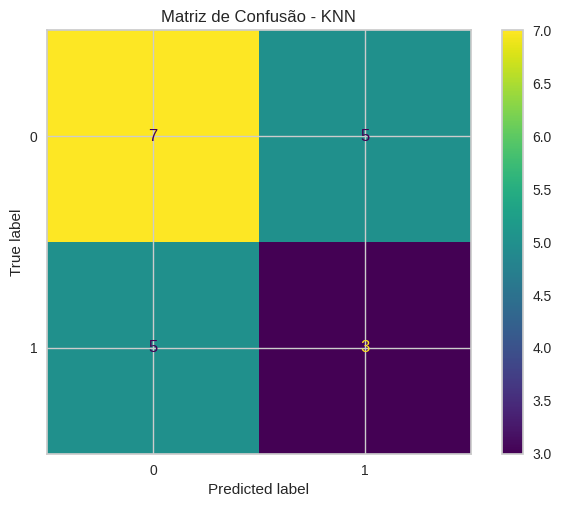

In [61]:
matriz_knn = confusion_matrix(Y_teste, previsores_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_knn)
disp.plot()
plt.title("Matriz de Confusão - KNN")
plt.show()

# Pipeline de Comparação dos mudelos

In [56]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calcular_metricas(nome_modelo, y_real, y_pred):
    return {
        "Modelo": nome_modelo,
        "Acurácia": accuracy_score(y_real, y_pred),
        "Precisão Weighted": precision_score(y_real, y_pred, average="weighted", zero_division=0),
        "Recall Weighted": recall_score(y_real, y_pred, average="weighted", zero_division=0),
        "F1-Score Weighted": f1_score(y_real, y_pred, average="weighted", zero_division=0)
    }


resultados_modelos = [
    calcular_metricas("Árvore de Decisão", Y_teste, previsoes_arvore),
    calcular_metricas("Random Forest", Y_teste, previsores_random),
    calcular_metricas("SVM", Y_teste, svm_previsoes),
    calcular_metricas("Rede Neural MLP", Y_teste, previsores_randeural),
    calcular_metricas("KNN", Y_teste, previsores_knn)
]


tabela_comparativa = pd.DataFrame(resultados_modelos)


tabela_comparativa = tabela_comparativa.sort_values(
    by="F1-Score Weighted",
    ascending=False
)


tabela_comparativa = tabela_comparativa.round(2)


tabela_comparativa

,Modelo,Acurácia,Precisão Weighted,Recall Weighted,F1-Score Weighted
0,Árvore de Decisão,0.70,0.72,0.70,0.70
1,Random Forest,0.60,0.62,0.60,0.60
3,Rede Neural MLP,0.55,0.52,0.55,0.52
4,KNN,0.50,0.50,0.50,0.50
2,SVM,0.60,0.36,0.60,0.45
